In [1]:
# CASE-18: Beacon Interval Visualization
## C2 Timing Analysis -- SSLoad + Cobalt Strike
### Analyst: Ronan Kongala | REMnux Ubuntu 24.04

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

LOG_PATH = '/home/remnux/case18-zeek-lab/zeek-logs/conn.log'

cols = []
data_rows = []
with open(LOG_PATH) as f:
    for line in f:
        if line.startswith('#fields'):
            cols = line.strip().split('\t')[1:]
        elif not line.startswith('#'):
            data_rows.append(line.strip().split('\t'))

df = pd.DataFrame(data_rows, columns=cols)
df['ts'] = pd.to_numeric(df['ts'], errors='coerce')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df['orig_bytes'] = pd.to_numeric(df['orig_bytes'], errors='coerce')
df['resp_bytes'] = pd.to_numeric(df['resp_bytes'], errors='coerce')

# Isolate C2 IP connections
c2_ip = '85.239.53.219'
c2_df = df[df['id.resp_h'] == c2_ip].sort_values('ts').reset_index(drop=True)
print(f"Connections to {c2_ip}: {len(c2_df)}")
print(c2_df[['ts','duration','orig_bytes','resp_bytes','conn_state']].to_string())

Connections to 85.239.53.219: 11
              ts     duration  orig_bytes  resp_bytes conn_state
0   1.713466e+09  1982.689438     29967.0    226570.0         SF
1   1.713466e+09     6.743542       118.0    208179.0       RSTO
2   1.713467e+09     6.686823       118.0    208179.0       RSTO
3   1.713468e+09    21.688691       118.0    208179.0       RSTO
4   1.713468e+09  1992.108742     30071.0     18652.0         SF
5   1.713468e+09     6.667222       118.0    208179.0       RSTO
6   1.713469e+09     6.754396       118.0    208179.0       RSTO
7   1.713469e+09     6.672386       118.0    208179.0       RSTO
8   1.713470e+09  1034.494020     15600.0      9620.0         S1
9   1.713470e+09    13.706299       118.0    208179.0       RSTO
10  1.713471e+09     9.769224       118.0    208179.0       RSTO


In [3]:
# Calculate inter-arrival intervals between beacon connections
c2_df['interval'] = c2_df['ts'].diff()
c2_df['ts_readable'] = pd.to_datetime(c2_df['ts'], unit='s')

print("=== BEACON INTERVALS (seconds between connections) ===")
intervals = c2_df['interval'].dropna()
print(f"Mean interval:   {intervals.mean():.1f}s")
print(f"Median interval: {intervals.median():.1f}s")
print(f"Std deviation:   {intervals.std():.1f}s")
print(f"Min interval:    {intervals.min():.1f}s")
print(f"Max interval:    {intervals.max():.1f}s")
print(f"\nJitter ratio: {(intervals.std()/intervals.mean()*100):.1f}%")
print("\nRaw intervals:")
print(intervals.to_string())

=== BEACON INTERVALS (seconds between connections) ===
Mean interval:   477.5s
Median interval: 586.4s
Std deviation:   169.2s
Min interval:    165.0s
Max interval:    606.9s

Jitter ratio: 35.4%

Raw intervals:
1     579.924154
2     601.834797
3     592.971522
4     227.962082
5     375.043990
6     600.132932
7     606.936036
8     429.998951
9     164.980319
10    594.989697


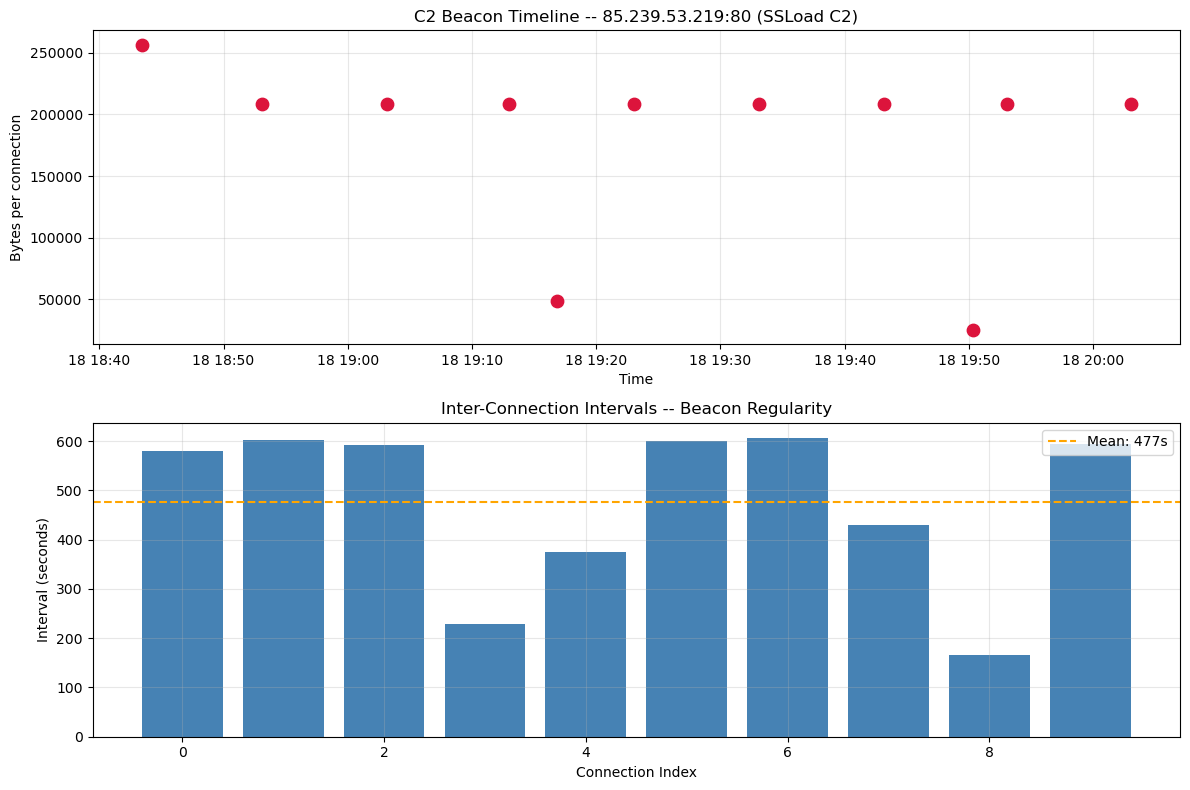

Plot saved.


In [4]:
# Visualize beacon timing
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: connection timeline
axes[0].scatter(c2_df['ts_readable'], 
                c2_df['orig_bytes'].fillna(0) + c2_df['resp_bytes'].fillna(0),
                color='crimson', s=80, zorder=5)
axes[0].set_title(f'C2 Beacon Timeline -- {c2_ip}:80 (SSLoad C2)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Bytes per connection')
axes[0].grid(True, alpha=0.3)

# Plot 2: interval consistency
intervals_clean = c2_df['interval'].dropna()
axes[1].bar(range(len(intervals_clean)), intervals_clean.values, color='steelblue')
axes[1].axhline(y=intervals_clean.mean(), color='orange', 
                linestyle='--', label=f'Mean: {intervals_clean.mean():.0f}s')
axes[1].set_title('Inter-Connection Intervals -- Beacon Regularity')
axes[1].set_xlabel('Connection Index')
axes[1].set_ylabel('Interval (seconds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/remnux/case18-zeek-lab/notebooks/beacon_intervals.png', dpi=150)
plt.show()
print("Plot saved.")